<h1><b> Librerías

In [1]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast, GradScaler          # ← AMP para RTX 5060
from torchvision import models, transforms

from sklearn.model_selection import StratifiedKFold  # ← KFold estratificado
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, f1_score
)
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = False   # False = más rápido con AMP
torch.backends.cudnn.benchmark     = True    # ← autooptimiza kernels para tu GPU

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Usando dispositivo:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM disponible:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")

PyTorch version: 2.14.0.dev20260621+cu132
Usando dispositivo: cuda
GPU: NVIDIA GeForce RTX 5060
VRAM disponible: 8.55 GB


<H1><b> Configuración global

In [5]:
# Rutas — KFold usa train+valid como pool; test queda intacto
FOLDER_POOL  = "sinteticas2/syn_spect_train"
FOLDER_VALID = "sinteticas2/syn_spect_valid"   # se fusiona al pool
FOLDER_TEST  = "sinteticas2/syn_spect_test"
MODEL_SAVE   = "model2_kfold_todos_los_slides/"
os.makedirs(MODEL_SAVE, exist_ok=True)

# Imagen
HEIGHT, WIDTH        = 256, 256
LOW_FRAME, TOP_FRAME = 0, 182

# Entrenamiento
BATCH_SIZE  = 64       # AMP reduce VRAM ~50%, RTX 5060 8GB aguanta 64
NUM_CLASES  = 2
EPOCHS      = 20
LR          = 1e-4
N_FOLDS     = 5        # 5-fold → cada fold valida ~20% del pool
NUM_WORKERS = 0        # Ryzen 7 5600 tiene 12 hilos lógicos

# Arquitectura
ARQUITECTURA = "MobileNet"  # opciones: MobileNet - ResNet50 - Vgg16

# Etiquetas
LABELS       = {"CN": 0, "AD": 1}
TARGET_NAMES = ["control", "parkinson"]

print("Configuración:")
print(f"  Dispositivo  : {DEVICE}")
print(f"  Imagen       : {HEIGHT}x{WIDTH}")
print(f"  Slices       : {LOW_FRAME} al {TOP_FRAME}  ({TOP_FRAME - LOW_FRAME} slices por volumen)")
print(f"  Batch size   : {BATCH_SIZE}  (con AMP)")
print(f"  Épocas       : {EPOCHS}")
print(f"  Folds        : {N_FOLDS}")
print(f"  LR           : {LR}")
print(f"  Workers      : {NUM_WORKERS}")
print(f"  Arquitectura : {ARQUITECTURA}")

Configuración:
  Dispositivo  : cuda
  Imagen       : 256x256
  Slices       : 0 al 182  (182 slices por volumen)
  Batch size   : 64  (con AMP)
  Épocas       : 20
  Folds        : 5
  LR           : 0.0001
  Workers      : 0
  Arquitectura : MobileNet


<h1><b> Splits

In [6]:
# Test fijo — nunca se toca durante KFold
TEST_IDS = {
    "3386", "3552", "3554", "3559", "3565", "3575", "3591", "3593",
    "3759", "3765", "3767", "3769", "3806", "3807", "3824", "3832",
    "3857", "3863"
}

print(f"Test fijo : {len(TEST_IDS)} sujetos")
print(f"El pool restante se divide en {N_FOLDS} folds automáticamente")

Test fijo : 18 sujetos
El pool restante se divide en 5 folds automáticamente


<h1><b> DataFrames

In [7]:
def scan_folder(folder):
    records = []
    for fname in sorted(os.listdir(folder)):
        if not fname.endswith(".nii.gz"):
            continue
        tokens           = fname.split("_")
        case_number      = tokens[0]
        file_label_token = tokens[1].upper()
        if file_label_token not in LABELS:
            continue
        records.append({
            "path":        os.path.join(folder, fname),
            "label":       file_label_token,
            "label_idx":   LABELS[file_label_token],
            "case_number": case_number,
        })
    return pd.DataFrame(records)


# Escanear las 3 carpetas y fusionar
df_train = scan_folder(FOLDER_POOL)
df_valid = scan_folder(FOLDER_VALID)
df_test  = scan_folder(FOLDER_TEST)
df_all   = pd.concat([df_train, df_valid, df_test], ignore_index=True)

# Separar por TEST_IDS
test_df = df_all[df_all["case_number"].isin(TEST_IDS)].reset_index(drop=True)
pool_df = df_all[~df_all["case_number"].isin(TEST_IDS)].reset_index(drop=True)

print("=" * 40)
print("DISTRIBUCIÓN DE VOLÚMENES")
print("=" * 40)
for name, df in [("Pool (KFold)", pool_df), ("Test", test_df)]:
    print(f"\n{name} — Total: {len(df)} volúmenes")
    print(df.groupby("label")["path"].count().to_string())

print(f"\nTotal cargado : {len(df_all)}")
print(f"En TEST_IDS   : {len(test_df)}  (esperado: {len(TEST_IDS)})")
faltantes = TEST_IDS - set(test_df["case_number"])
if faltantes:
    print(f"IDs no encontrados en disco: {faltantes}")

DISTRIBUCIÓN DE VOLÚMENES

Pool (KFold) — Total: 166 volúmenes
label
AD    102
CN     64

Test — Total: 18 volúmenes
label
AD    9
CN    9

Total cargado : 184
En TEST_IDS   : 18  (esperado: 18)


<h1><b> Dataset y DataLoader

- Lee volúmenes .nii.gz, extrae los slices axiales entre LOW_FRAME y TOP_FRAME
- convierte a tensor RGB (3, H, W)
- Cada slice es una muestra independiente.

In [8]:
class SPECTDataset(Dataset):

    def __init__(self, df, transform=None):
        self.transform = transform
        self.samples   = []

        for _, row in df.iterrows():
            vol = nib.load(row["path"]).get_fdata()
            num_slices = vol.shape[2]

            for s in range(LOW_FRAME, min(TOP_FRAME, num_slices)):
                self.samples.append((
                    row["path"],
                    row["label_idx"],
                    row["case_number"],
                    s
                ))

        print(f"  Dataset listo: {len(self.samples)} slices")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, case_number, slice_idx = self.samples[idx]

        vol      = nib.load(path).get_fdata()
        slice_2d = vol[:, :, slice_idx].astype(np.float32)

        s_min, s_max = slice_2d.min(), slice_2d.max()
        if s_max > s_min:
            slice_2d = (slice_2d - s_min) / (s_max - s_min)

        slice_img = plt.cm.gray(slice_2d)[:, :, :3]
        slice_img = (slice_img * 255).astype(np.uint8)

        from PIL import Image
        img = Image.fromarray(slice_img).resize((WIDTH, HEIGHT))

        if self.transform:
            img = self.transform(img)

        return img, label, case_number


# Transformaciones
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),              # ← augmentation ligero para datos escasos
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# Solo test se pre-construye — train/val los crea KFold en cada fold
test_dataset = SPECTDataset(test_df, transform=val_test_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Test slices : {len(test_dataset)}")

  Dataset listo: 3276 slices
Test slices : 3276


<h1><b> Modelo de entrenamiento

- Cargar un modelo preentrenado en ImageNet
- Se congelan las primeras n capas por modelo, las primeras capas detectan cosas genéricas (bordes, texturas)
- Se reemplaza la cabeza de clasificación para num_clases clases

In [9]:
def make_model(arquitectura, num_clases):

    if arquitectura == "MobileNet":
        base_model = models.mobilenet_v2(weights="IMAGENET1K_V1")
        # Congelar las primeras capas
        for i, param in enumerate(base_model.parameters()):
            if i < 70:
                param.requires_grad = False
        # Reemplazar cabeza
        in_features = base_model.classifier[1].in_features
        base_model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, num_clases)
        )

    elif arquitectura == "ResNet50":
        base_model = models.resnet50(weights="IMAGENET1K_V1")
        for i, param in enumerate(base_model.parameters()):
            if i < 100:
                param.requires_grad = False
        in_features = base_model.fc.in_features
        base_model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, num_clases)
        )

    elif arquitectura == "Vgg16":
        base_model = models.vgg16(weights="IMAGENET1K_V1")
        for i, param in enumerate(base_model.parameters()):
            if i < 10:
                param.requires_grad = False
        in_features = base_model.classifier[6].in_features
        base_model.classifier[6] = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, num_clases)
        )

    else:
        raise ValueError(f"Arquitectura no soportada: {arquitectura}")

    model = base_model.to(DEVICE)

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parámetros totales    : {total_params:,}")
    print(f"  Parámetros entrenables: {trainable_params:,}")

    return model

# Instanciar
# model = make_model(ARQUITECTURA, NUM_CLASES)

<h1><b> Entrenamiento

In [10]:
def train_model(model, train_loader, val_loader, fold_idx):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR
    )

    best_val_acc  = 0.0
    epochs_no_imp = 0
    history       = {"train_loss": [], "train_acc": [],
                     "val_loss":   [], "val_acc":   []}
    best_path     = os.path.join(MODEL_SAVE, f"{ARQUITECTURA}_fold{fold_idx}.pth")

    for epoch in range(EPOCHS):

        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for imgs, labels, _ in tqdm(train_loader, desc=f"Fold {fold_idx} Epoch {epoch+1}/{EPOCHS}"):
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss    += loss.item() * imgs.size(0)
            preds          = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total   += imgs.size(0)

        train_loss /= train_total
        train_acc   = train_correct / train_total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for imgs, labels, _ in val_loader:
                imgs   = imgs.to(DEVICE)
                labels = labels.to(DEVICE)
                outputs     = model(imgs)
                loss        = criterion(outputs, labels)
                val_loss   += loss.item() * imgs.size(0)
                preds       = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total   += imgs.size(0)

        val_loss /= val_total
        val_acc   = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"  Epoch {epoch+1:02d} | "
              f"train_loss: {train_loss:.4f}  train_acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc  = val_acc
            epochs_no_imp = 0
            torch.save(model.state_dict(), best_path)
            print(f"  ✓ Fold {fold_idx} mejor modelo guardado (val_acc: {best_val_acc:.4f})")
        else:
            epochs_no_imp += 1
            print(f"  Sin mejora ({epochs_no_imp}/7)")
            if epochs_no_imp >= 7:
                print(f"  EarlyStopping fold {fold_idx}.")
                break

    return model, history, best_val_acc, best_path

In [ ]:
skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []  # guarda (fold_idx, best_val_acc, best_path)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(pool_df, pool_df["label_idx"]), start=1):

    print(f"\n{'='*50}")
    print(f"  FOLD {fold_idx}/{N_FOLDS}")
    print(f"{'='*50}")

    train_fold_df = pool_df.iloc[train_idx].reset_index(drop=True)
    val_fold_df   = pool_df.iloc[val_idx].reset_index(drop=True)

    train_dataset = SPECTDataset(train_fold_df, transform=train_transform)
    val_dataset   = SPECTDataset(val_fold_df,   transform=val_test_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    model = make_model(ARQUITECTURA, NUM_CLASES)

    model, history, best_val_acc, best_path = train_model(model, train_loader, val_loader, fold_idx)

    fold_results.append((fold_idx, best_val_acc, best_path))
    print(f"  Fold {fold_idx} terminado — mejor val_acc: {best_val_acc:.4f}")

# Resumen de folds
print(f"\n{'='*50}")
print("RESUMEN KFOLD")
print(f"{'='*50}")
for fold_idx, acc, path in fold_results:
    print(f"  Fold {fold_idx} | val_acc: {acc:.4f} | {path}")

# Mejor fold
best_fold = max(fold_results, key=lambda x: x[1])
print(f"\n  Mejor fold: {best_fold[0]} con val_acc: {best_fold[1]:.4f}")
print(f"  Pesos: {best_fold[2]}")


  FOLD 1/5
  Dataset listo: 24024 slices
  Dataset listo: 6188 slices
  Parámetros totales    : 4,061,442
  Parámetros entrenables: 3,930,754


Fold 1 Epoch 1/20: 100%|██████████| 376/376 [1:28:35<00:00, 14.14s/it]


  Epoch 01 | train_loss: 0.1000  train_acc: 0.9590 | val_loss: 0.2198  val_acc: 0.9392
  ✓ Fold 1 mejor modelo guardado (val_acc: 0.9392)


Fold 1 Epoch 2/20:  22%|██▏       | 82/376 [19:28<1:08:25, 13.97s/it]

<h1><b>Evaluación por sujeto

  Parámetros totales    : 4,061,442
  Parámetros entrenables: 3,930,754

##################################################
  FOLD 1 — MobileNet_fold1.pth
##################################################


Fold 1: 100%|██████████| 4/4 [00:46<00:00, 11.60s/it]



  Slice:
    AUC                 : 0.3402
    Balanced Accuracy   : 0.5000
    Recall              : 1.0000
    Specificity         : 0.0000
    F1-Score            : 0.6667

  Sujeto:
    AUC                 : 0.2346
    Balanced Accuracy   : 0.5000
    Recall              : 1.0000
    Specificity         : 0.0000
    F1-Score            : 0.6667


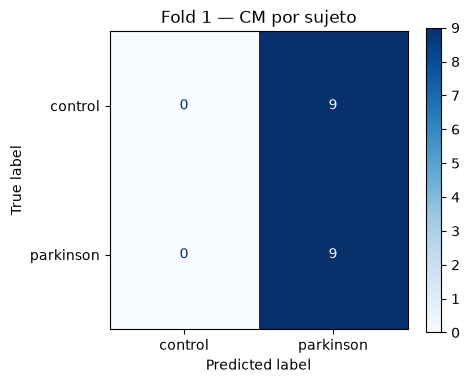


##################################################
  FOLD 2 — MobileNet_fold2.pth
##################################################


Fold 2: 100%|██████████| 4/4 [00:47<00:00, 11.95s/it]



  Slice:
    AUC                 : 0.3975
    Balanced Accuracy   : 0.5000
    Recall              : 1.0000
    Specificity         : 0.0000
    F1-Score            : 0.6667

  Sujeto:
    AUC                 : 0.3086
    Balanced Accuracy   : 0.5000
    Recall              : 1.0000
    Specificity         : 0.0000
    F1-Score            : 0.6667


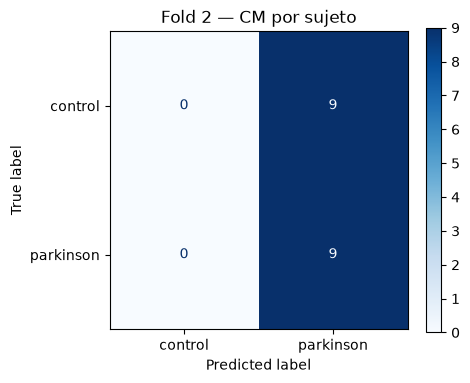


##################################################
  FOLD 3 — MobileNet_fold3.pth
##################################################


Fold 3: 100%|██████████| 4/4 [00:47<00:00, 11.88s/it]



  Slice:
    AUC                 : 0.3191
    Balanced Accuracy   : 0.5000
    Recall              : 1.0000
    Specificity         : 0.0000
    F1-Score            : 0.6667

  Sujeto:
    AUC                 : 0.1975
    Balanced Accuracy   : 0.5000
    Recall              : 1.0000
    Specificity         : 0.0000
    F1-Score            : 0.6667


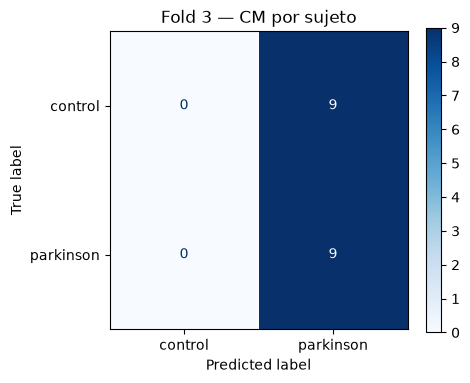


##################################################
  FOLD 4 — MobileNet_fold4.pth
##################################################


Fold 4: 100%|██████████| 4/4 [00:48<00:00, 12.11s/it]



  Slice:
    AUC                 : 0.3954
    Balanced Accuracy   : 0.4861
    Recall              : 0.9352
    Specificity         : 0.0370
    F1-Score            : 0.6454

  Sujeto:
    AUC                 : 0.3333
    Balanced Accuracy   : 0.5000
    Recall              : 1.0000
    Specificity         : 0.0000
    F1-Score            : 0.6667


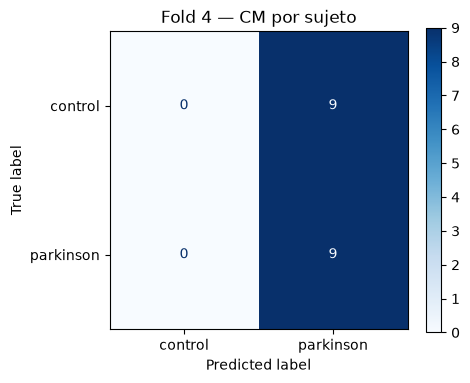


##################################################
  FOLD 5 — MobileNet_fold5.pth
##################################################


Fold 5: 100%|██████████| 4/4 [00:47<00:00, 11.91s/it]



  Slice:
    AUC                 : 0.3978
    Balanced Accuracy   : 0.4676
    Recall              : 0.8519
    Specificity         : 0.0833
    F1-Score            : 0.6154

  Sujeto:
    AUC                 : 0.3086
    Balanced Accuracy   : 0.5000
    Recall              : 1.0000
    Specificity         : 0.0000
    F1-Score            : 0.6667


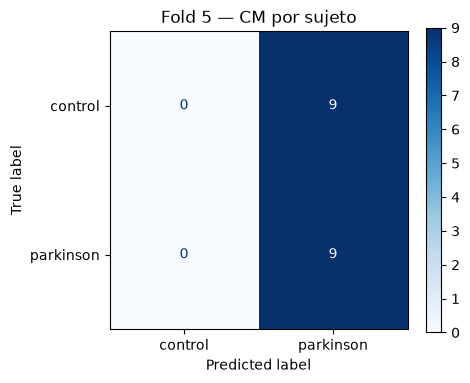


  RESUMEN GLOBAL K-FOLD

  Slice:
    AUC                 : 0.3700 ± 0.0336
    Balanced Accuracy   : 0.4907 ± 0.0128
    Recall              : 0.9574 ± 0.0584
    Specificity         : 0.0241 ± 0.0329
    F1-Score            : 0.6522 ± 0.0201

  Sujeto:
    AUC                 : 0.2765 ± 0.0516
    Balanced Accuracy   : 0.5000 ± 0.0000
    Recall              : 1.0000 ± 0.0000
    Specificity         : 0.0000 ± 0.0000
    F1-Score            : 0.6667 ± 0.0000


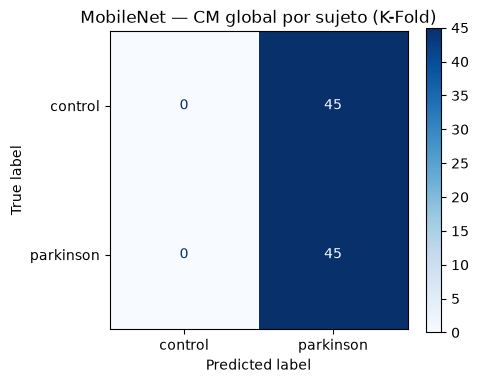


Resumen guardado en: model2_kfold_sin_cy_sin_clinicas/kfold_resumen_global.txt


In [28]:
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import glob

def get_metrics_kfold(model, loader_fn, weights_dir, k=5):
    """
    loader_fn: función que recibe el fold y retorna el test_loader de ese fold
               si usas el mismo loader para todos, pasa lambda fold: test_loader
    weights_dir: carpeta con los 5 .pth, se ordenan alfabéticamente
    """

    weights_list = sorted(glob.glob(os.path.join(weights_dir, "*.pth")))
    assert len(weights_list) == k, f"Se esperaban {k} pesos, se encontraron {len(weights_list)}"

    all_fold_slice  = []
    all_fold_subj   = []

    # Para confusion matrix global por sujeto
    all_subj_labels_global = []
    all_subj_preds_global  = []

    for fold_idx, weights_path in enumerate(weights_list):
        print(f"\n{'#'*50}")
        print(f"  FOLD {fold_idx + 1} — {os.path.basename(weights_path)}")
        print(f"{'#'*50}")

        loader = loader_fn(fold_idx)

        model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
        model.eval()

        all_labels, all_preds, all_probs = [], [], []
        subject_data = {}

        with torch.no_grad():
            for imgs, labels, case_numbers in tqdm(loader, desc=f"Fold {fold_idx+1}"):
                imgs = imgs.to(DEVICE)
                outputs = model(imgs)
                probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
                preds = outputs.argmax(dim=1).cpu().numpy()
                labels_np = labels.numpy()

                all_labels.extend(labels_np)
                all_preds.extend(preds)
                all_probs.extend(probs)

                for case, pred, prob, label in zip(case_numbers, preds, probs, labels_np):
                    if case not in subject_data:
                        subject_data[case] = {"label": int(label), "preds": [], "probs": []}
                    subject_data[case]["preds"].append(int(pred))
                    subject_data[case]["probs"].append(float(prob))

        subj_labels, subj_preds, subj_probs = [], [], []
        for case, d in sorted(subject_data.items()):
            subj_labels.append(d["label"])
            subj_preds.append(1 if sum(d["preds"]) >= len(d["preds"]) / 2 else 0)
            subj_probs.append(sum(d["probs"]) / len(d["probs"]))

        all_subj_labels_global.extend(subj_labels)
        all_subj_preds_global.extend(subj_preds)

        def compute(y_true, y_pred, y_prob):
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            return {
                "AUC":               roc_auc_score(y_true, y_prob),
                "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
                "Recall":            recall_score(y_true, y_pred),
                "Specificity":       tn / (tn + fp),
                "F1-Score":          f1_score(y_true, y_pred),
            }

        slice_m = compute(all_labels, all_preds, all_probs)
        subj_m  = compute(subj_labels, subj_preds, subj_probs)

        for name, m in [("Slice", slice_m), ("Sujeto", subj_m)]:
            print(f"\n  {name}:")
            for k_name, v in m.items():
                print(f"    {k_name:20s}: {v:.4f}")

        all_fold_slice.append(slice_m)
        all_fold_subj.append(subj_m)

        # Confusion matrix por sujeto de este fold
        cm = confusion_matrix(subj_labels, subj_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
        fig, ax = plt.subplots(figsize=(5, 4))
        disp.plot(cmap=plt.cm.Blues, values_format="d", ax=ax)
        ax.set_title(f"Fold {fold_idx+1} — CM por sujeto")
        plt.tight_layout()
        plt.savefig(os.path.join(weights_dir, f"fold{fold_idx+1}_cm_sujeto.png"), dpi=150)
        plt.show()

    # ── Resumen global ──────────────────────────────────────────────
    print(f"\n{'='*50}")
    print("  RESUMEN GLOBAL K-FOLD")
    print(f"{'='*50}")

    for nivel, fold_metrics in [("Slice", all_fold_slice), ("Sujeto", all_fold_subj)]:
        print(f"\n  {nivel}:")
        keys = list(fold_metrics[0].keys())
        for k_name in keys:
            vals = [m[k_name] for m in fold_metrics]
            print(f"    {k_name:20s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

    # Confusion matrix global por sujeto (todos los folds)
    cm_global = confusion_matrix(all_subj_labels_global, all_subj_preds_global)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_global, display_labels=TARGET_NAMES)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap=plt.cm.Blues, values_format="d", ax=ax)
    ax.set_title(f"{ARQUITECTURA} — CM global por sujeto (K-Fold)")
    plt.tight_layout()
    plt.savefig(os.path.join(weights_dir, "kfold_cm_sujeto_global.png"), dpi=150)
    plt.show()

    # Guardar resumen global en txt
    txt_path = os.path.join(weights_dir, "kfold_resumen_global.txt")
    with open(txt_path, "w") as f:
        f.write(f"RESUMEN GLOBAL K-FOLD — {ARQUITECTURA}\n")
        f.write("="*50 + "\n")
        for nivel, fold_metrics in [("Slice", all_fold_slice), ("Sujeto", all_fold_subj)]:
            f.write(f"\n{nivel}:\n")
            keys = list(fold_metrics[0].keys())
            for k_name in keys:
                vals = [m[k_name] for m in fold_metrics]
                f.write(f"  {k_name:20s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}\n")
        f.write("\nMétricas por fold (Sujeto):\n")
        for i, m in enumerate(all_fold_subj):
            f.write(f"\n  Fold {i+1}:\n")
            for k_name, v in m.items():
                f.write(f"    {k_name:20s}: {v:.4f}\n")
    print(f"\nResumen guardado en: {txt_path}")

    return all_fold_slice, all_fold_subj


model = make_model(ARQUITECTURA, NUM_CLASES)

# --- USO ---
WEIGHTS_DIR = "model2_kfold_sin_cy_sin_clinicas/"

# Si usas el mismo loader para todos los folds:
slice_metrics, subj_metrics = get_metrics_kfold(
    model,
    loader_fn=lambda fold: test_loader,
    weights_dir=WEIGHTS_DIR
)